In [52]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import make_regression, make_moons

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 0

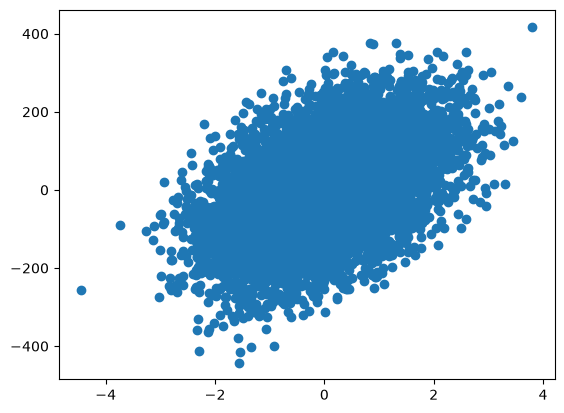

In [49]:
X, y = make_regression(n_samples= 10000, n_features=2, n_informative=2, n_targets=1, noise=0.2, random_state= RANDOM_STATE)

import matplotlib.pyplot as plt

plt.scatter(X[:,0], y)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (sklearn)": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}
print("\n" + "=" * 70)
print("REGRESSION — Diabetes dataset (target: disease progression, 1yr later)")
print("=" * 70)
print(f"{'Model':<28}{'RMSE':>10}{'MAE':>10}{'R2':>10}{'Train(s)':>12}")
print("-" * 70)
results = []
for name, model in models.items():
    Xtr = X_train_s if name == "Linear Regression" else X_train
    Xte = X_test_s if name == "Linear Regression" else X_test
    start = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - start
    preds = model.predict(Xte)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append((name, rmse, mae, r2, train_time))
    print(f"{name:<28}{rmse:>10.4f}{mae:>10.4f}{r2:>10.4f}{train_time:>12.3f}")


REGRESSION — Diabetes dataset (target: disease progression, 1yr later)
Model                             RMSE       MAE        R2    Train(s)
----------------------------------------------------------------------
Linear Regression               0.3284    0.2587    0.5686       0.009
Decision Tree                   0.2776    0.1554    0.6917       0.012
Random Forest                   0.2504    0.1330    0.7493       0.758
Gradient Boosting (sklearn)     0.2466    0.1446    0.7568       1.169
XGBoost                         0.2902    0.2316    0.6632       0.181


<Axes: >

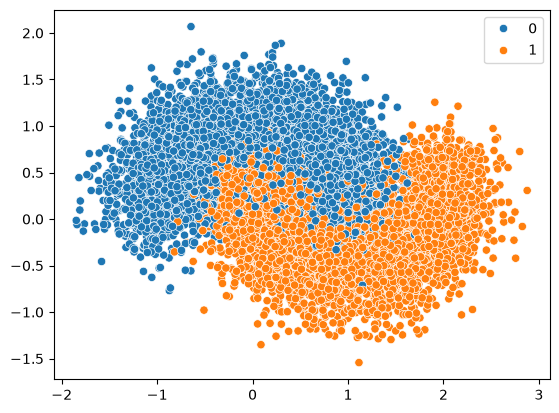

In [55]:
X, y = make_moons(n_samples=10000, random_state=RANDOM_STATE, noise = 0.3)

import seaborn as sns

sns.scatterplot(x = X[:,0],y = X[:, 1], hue=y)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (sklearn)": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}
print("\n" + "=" * 70)
print("CLASSIFICATION — Breast Cancer Wisconsin (binary: malignant/benign)")
print("=" * 70)
print(f"{'Model':<28}{'Accuracy':>10}{'F1':>10}{'ROC-AUC':>10}{'Train(s)':>12}")
print("-" * 70)
results = []
for name, model in models.items():
    Xtr = X_train_s if name == "Logistic Regression" else X_train
    Xte = X_test_s if name == "Logistic Regression" else X_test
    start = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - start
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results.append((name, acc, f1, auc, train_time))
    print(f"{name:<28}{acc:>10.4f}{f1:>10.4f}{auc:>10.4f}{train_time:>12.3f}")


CLASSIFICATION — Breast Cancer Wisconsin (binary: malignant/benign)
Model                         Accuracy        F1   ROC-AUC    Train(s)
----------------------------------------------------------------------
Logistic Regression             0.8610    0.8616    0.9372       0.029
Decision Tree                   0.9105    0.9095    0.9647       0.018
Random Forest                   0.9210    0.9202    0.9719       1.317
Gradient Boosting (sklearn)     0.9195    0.9189    0.9738       2.765
XGBoost                         0.9180    0.9174    0.9727       0.478
